In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image
# Note: OpenCV loads images in BGR format by default, not RGB!

In [3]:

img_path = '../data/raw/sample_1.jpg'  # Make sure path is correct
image = cv.imread(img_path)

if image is None:
    print("Error: Could not load image. Check the path.")
    # Exit if image not found
    exit()
# 2. Inspect the Data Structure (The "C# vs Python" lesson)
print(f"Type: {type(image)}")       # It's a numpy.ndarray
print(f"Shape: {image.shape}")      # (Height, Width, 3 Channels)
print(f"Data Type: {image.dtype}")  # uint8 (0-255)
# Let's look at a single pixel value at [100, 100]
px = image[100, 100]
print(f"Pixel at [100,100] (BGR): {px}")

Type: <class 'numpy.ndarray'>
Shape: (512, 348, 3)
Data Type: uint8
Pixel at [100,100] (BGR): [180 182 182]


3. Preprocessing and Visualization

Gray Shape: (512, 348)


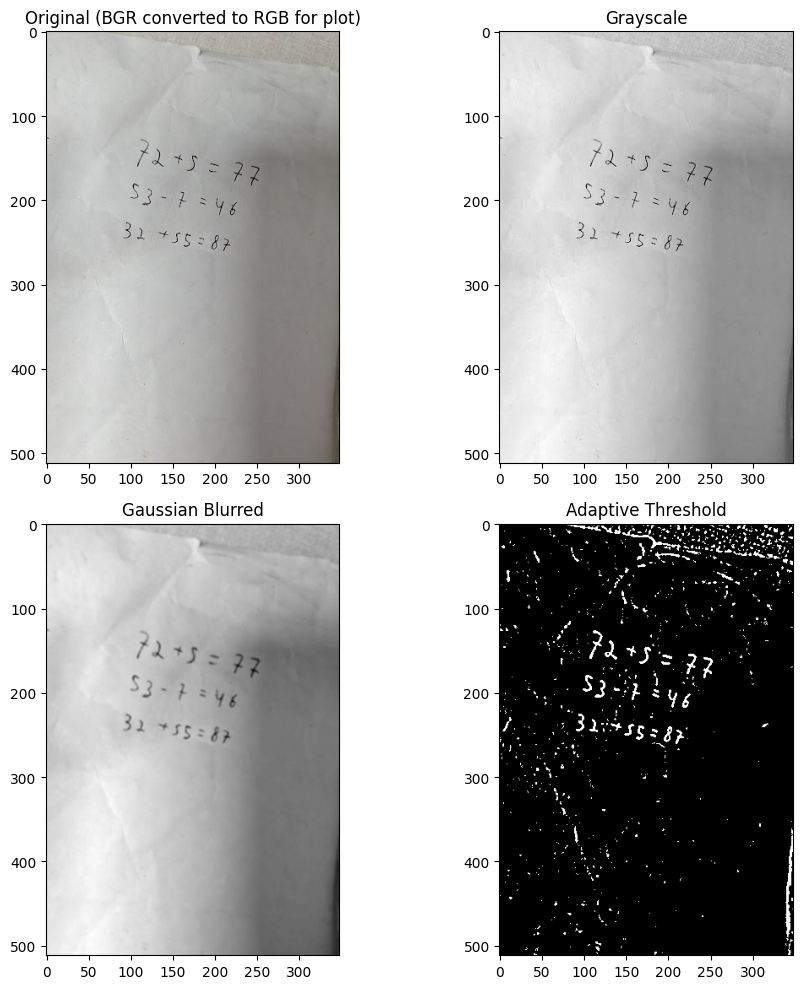

In [4]:
# We don't need color for digit recognition. It's noise.
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
print(f"Gray Shape: {gray.shape}") # Notice channels are gone. It's 2D now.

# Further processing
gausian = cv.GaussianBlur(gray, (5, 5), -5)
th3 = cv.adaptiveThreshold(gausian,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
                           cv.THRESH_BINARY_INV,11,2)


# Visualization
plt.figure(figsize=(10, 10))
    
plt.subplot(2, 2, 1)
plt.title("Original (BGR converted to RGB for plot)")
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    
plt.subplot(2, 2, 2)
plt.title("Grayscale")
plt.imshow(gray, cmap='gray')

plt.subplot(2, 2, 3)
plt.title("Gaussian Blurred")
plt.imshow(gausian, cmap='gray')

plt.subplot(2, 2, 4)
plt.title("Adaptive Threshold")
plt.imshow(th3, cmap='gray')
    
plt.tight_layout()
plt.show()

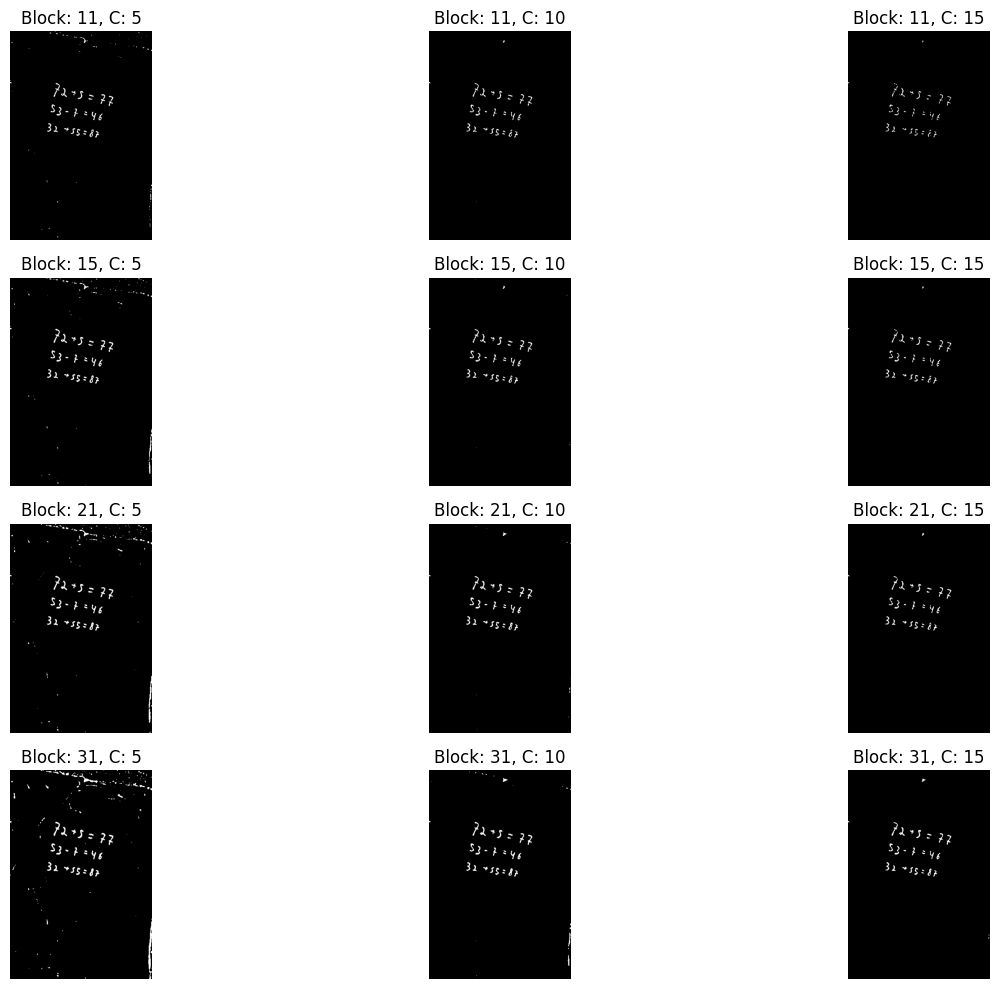

In [7]:
# Grid Search for Parameters
block_sizes = [11, 15, 21, 31] # חייב להיות אי-זוגי!
c_values = [5, 10, 15]

plt.figure(figsize=(15, 10))
plot_idx = 1

for bs in block_sizes:
    for c in c_values:
        # Apply Threshold
        thresh_test = cv.adaptiveThreshold(
            gausian, 
            255, 
            cv.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv.THRESH_BINARY_INV, 
            bs, 
            c
        )
        
        # Plot
        plt.subplot(len(block_sizes), len(c_values), plot_idx)
        plt.imshow(thresh_test, cmap='gray')
        plt.title(f"Block: {bs}, C: {c}")
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()